In [7]:
import warnings
warnings.filterwarnings('ignore')

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import shutil

## Defining ROOT and Working Directories

In [9]:
ROOT_DIR_target = '6_classes_pins_dataset'
ROOT_DIR_nontarget = '105_classes_pins_dataset'
DEST_DIR = './Data'

## Resetting Data in case of Re-Use ##

In [10]:
# shutil.rmtree("./Data")
# shutil.rmtree("./Model_Data")
# shutil.rmtree("./Model")

## Randomly choosing 'N' targets from the ROOT Dataset along with a category other than the 'N' targets consisting of miscellaneous other persons

In [11]:
n = 6  #int(input("Enter Number of Targets: "))
#shutil.rmtree("./Data")
import random   
exclude=[]
target=[]
count=[]
no_of_images = {}

if not os.path.exists("./Data"):
    os.mkdir("./Data")
    for person in os.listdir(ROOT_DIR_target):
        src = (ROOT_DIR_target+'/'+person)
        dest = ('./Data/'+person[5:])
        exclude.append(person)
        shutil.copytree(src,dest)
    for dir in os.listdir(DEST_DIR):
        no_of_images[dir] = len(os.listdir(os.path.join(DEST_DIR,dir)))
    othersno=max(no_of_images.values())
    
    if not os.path.exists("./Data/NON-TARGET"):
        os.mkdir("./Data/NON-TARGET")
        personfolder=os.listdir(ROOT_DIR_nontarget)
        for i in range(othersno+2):
            person=random.choice(personfolder)
            while person in exclude:
                person=random.choice(personfolder)
            files=os.listdir(ROOT_DIR_nontarget+'/'+person)
            face=random.choice(files)
            src = (ROOT_DIR_nontarget+'/'+person+'/'+face)
            dest = ('./Data/NON-TARGET/')
            shutil.copy(src,dest)
        
no_of_images = {}
for dir in os.listdir(DEST_DIR):
    no_of_images[dir] = len(os.listdir(os.path.join(DEST_DIR,dir)))
no_of_images.items()
print('\n')
for item in no_of_images:
    if item != 'NON-TARGET':
        target.append(item)
print('Target_Name\t\tNo_of_Images')
for item in target:
    print(item,'\t\t',no_of_images[item])
print('NON-TARGET','\t\t',no_of_images['NON-TARGET'])



Target_Name		No_of_Images
Brenton Thwaites 		 209
Brian J. Smith 		 102
barbara palvin 		 197
Bobby Morley 		 138
Bill Gates 		 122
Brie Larson 		 169
NON-TARGET 		 209


## Splitting dataset
### Train = 70%, 
### Validation = 30%
### Test = 50%

In [12]:
def dataFolder(p, split):
    if not os.path.exists("./Model_Data"):
        os.mkdir("./Model_Data")
    if not os.path.exists("./Model_Data/"+p):
        os.mkdir("./Model_Data/"+p)
        for dir in os.listdir(DEST_DIR):
            os.makedirs("./Model_Data/"+p+"/"+dir)
            for img in np.random.choice(a=os.listdir(os.path.join(DEST_DIR,dir)), size = (math.floor(split*no_of_images[dir])-5),replace=False):
                O = os.path.join(DEST_DIR,dir,img)
                D = os.path.join("./Model_Data/"+p,dir)
                shutil.copy(O,D)
    else:
        print(f"{p} Exists")

In [13]:
dataFolder("Train",0.7)
dataFolder("Val",0.3)
dataFolder("Test",0.5)

## Image Preprocessing with image resolution of (256 x 256) of 3 channels, RGB

In [14]:
from keras.preprocessing.image import ImageDataGenerator

def preprocessingTrain(path):
    image_data = ImageDataGenerator(featurewise_center=True,
                                    rotation_range=0.4,
                                    width_shift_range=0.3,
                                    zoom_range=0.2,
                                    shear_range=0.2,
                                    rescale=1./255,
                                    horizontal_flip= True)

    image = image_data.flow_from_directory(directory= path,
                                           target_size=(256,256),
                                           batch_size=32,
                                           class_mode='categorical')
    return image

def preprocessingVal(path):
    image_data = ImageDataGenerator(rescale=1./255)
    image = image_data.flow_from_directory(directory= path,
                                           target_size=(256,256),
                                           batch_size=32,
                                           class_mode='categorical')
    return image

In [15]:
train_path="./Model_Data/Train"
train_data = preprocessingTrain(train_path)

Found 764 images belonging to 7 classes.


In [16]:
val_path="./Model_Data/Val"
val_data = preprocessingVal(val_path)

Found 305 images belonging to 7 classes.


In [17]:
test_path="./Model_Data/Test"
test_data = preprocessingVal(test_path)

Found 536 images belonging to 7 classes.


## Model Creation with Transfer Learning 
### Model Used: Inception_ResNet_V2
### Output Classes = n+1

In [18]:
from keras.models import Model
from keras.layers import Flatten, Dense
import keras.losses
from keras.applications.inception_resnet_v2 import InceptionResNetV2 as IncRes

In [19]:
# base_model = IncRes(input_shape=(256,256,3),weights='imagenet',include_top=False)
# for layer in base_model.layers:
#     layer.trainable=False

# X=Flatten()(base_model.output)
# X=Dense(units=n+1, activation='softmax')(X)

# model_IncRes = Model(base_model.input, X)

# model_IncRes.compile(optimizer='adam',loss=keras.losses.categorical_crossentropy,metrics=['accuracy'])
# model_IncRes.summary()

### Saving best model using Model Checkpoint as callbacks

In [20]:
# from keras.callbacks import ModelCheckpoint
# mcIncRes= ModelCheckpoint(filepath="./Model/FaceRecog.hdf5", monitor="val_accuracy", verbose=1, save_best_only= True)
# cbIncRes=[mcIncRes]

## Fit-Evaluation of model...
### Epochs = 100
### Training data: train_data
### Validation data: val_data
### Training steps per Epochs = 10
### Validation steps per Epochs = 8

In [21]:
# his_IncRes = model_IncRes.fit_generator(train_data, steps_per_epoch= 10, epochs= 100, validation_data= val_data , validation_steps= 8, callbacks=cbIncRes)

In [22]:
# model_IncRes.save('model2_6class.h5')

In [23]:
# import json

# json_object = json.dumps(his_IncRes, indent=4)

### Model Accuracy and Loss Plots 

In [ ]:
# hIncRes = his_IncRes.history
# hIncRes.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

NameError: name 'hIncRes' is not defined

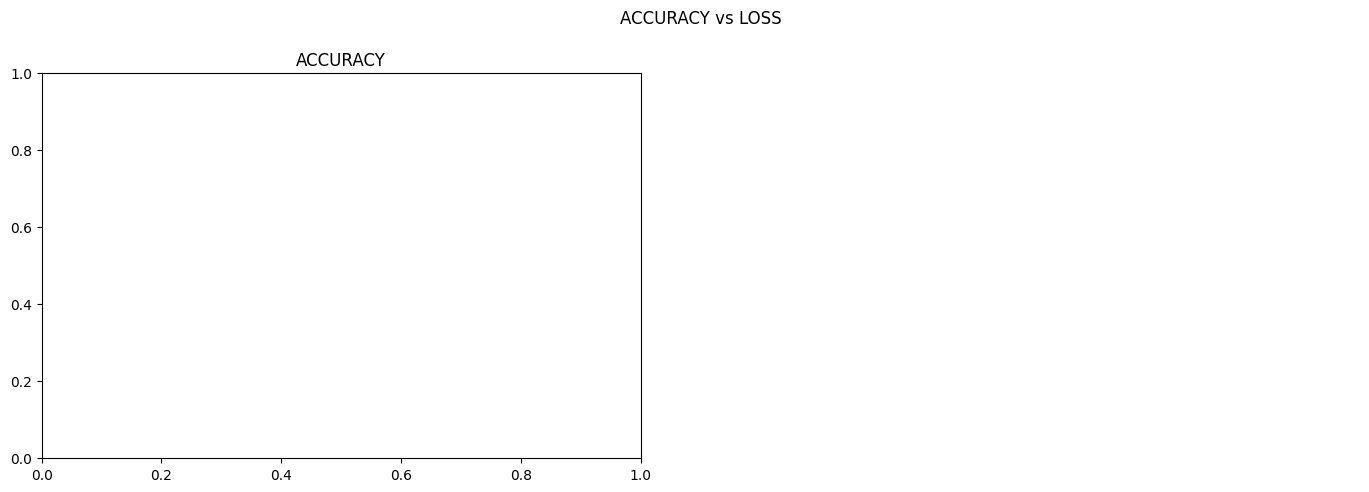

In [24]:
# fig = plt.figure(figsize=(17, 5))
# plt.axis("off")
# plt.title("ACCURACY vs LOSS\n\n")
# rows = 1
# columns = 2
# fig.add_subplot(rows, columns, 1)
# plt.title("ACCURACY")
# plt.plot(hIncRes['accuracy'], c='blue')
# plt.plot(hIncRes['val_accuracy'], c='red')
# fig.add_subplot(rows, columns, 2)
# plt.title("LOSS")
# plt.plot(hIncRes['loss'], c='blue')
# plt.plot(hIncRes['val_loss'], c='red')


## Defining the classes for labelling the final outcome

In [25]:
classes = val_data.class_indices

classes = list(classes.keys())

for i in range(0,n+1):
    classes[i]=classes[i]

## Importing the Saved Best-Model File 

In [30]:
from tensorflow import keras
model = keras.models.load_model("model2_6class.h5")

ValueError: bad marshal data (unknown type code)

# Predicting a random Celebrity Picture using the model and showing it's Class Output

In [3]:
from tensorflow.keras.preprocessing import image
def random_face():
    personfolder=os.listdir('./Model_Data/Test')
    person=random.choice(personfolder)
    files=os.listdir('./Model_Data/Test/'+person)
    imgpath=random.choice(files)
    return './Model_Data/Test/'+person+"/"+imgpath

from keras.applications.inception_resnet_v2 import preprocess_input
path = random_face()

img= image.load_img(path, target_size=(256,256,3))
plt.imshow(img)
plt.axis("off")
i = image.img_to_array(img)
i=preprocess_input(i)
input_arr = np.array([i])

pred= np.argmax(model.predict(input_arr))

print(classes[pred])

NameError: name 'random' is not defined